In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix

In [1]:
from sklearn.datasets import fetch_20newsgroups
data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [2]:
categories = ['talk.politics.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

In [3]:
print(train.data[5])

From: jbatka@desire.wright.edu
Subject: Re: Gamma Ray Bursters.  WHere  are they.
Organization:  Wright State University 
Lines: 16

I assume that can only be guessed at by the assumed energy of the
event and the 1/r^2 law.  So, if the 1/r^2 law is incorrect (assume
some unknown material [dark matter??] inhibits Gamma Ray propagation),
could it be possible that we are actually seeing much less energetic
events happening much closer to us?  The even distribution could
be caused by the characteristic propagation distance of gamma rays 
being shorter then 1/2 the thickness of the disk of the galaxy.

Just some idle babbling,
-- 

   Jim Batka  | Work Email:  BATKAJ@CCMAIL.DAYTON.SAIC.COM | Elvis is
              | Home Email:  JBATKA@DESIRE.WRIGHT.EDU      |   DEAD!

    64 years is 33,661,440 minutes ...
             and a minute is a LONG time!  - Beatles:  _ Yellow Submarine_



In [18]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB())
model.fit(train.data, train.target)
labels = model.predict(test.data)

accuracy_score(test.data, labels)

0.0

Text(113.92222222222219, 0.5, 'predicted label')

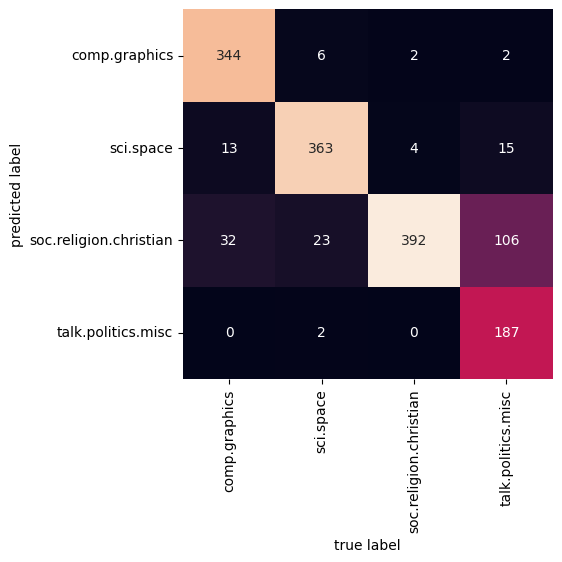

In [10]:
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

In [11]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

In [13]:
predict_category('sending a payload to the ISS')

'sci.space'

In [15]:
predict_category('discussing islam vs atheism')

'soc.religion.christian'

In [16]:
predict_category('determining the screen resolution')

'comp.graphics'

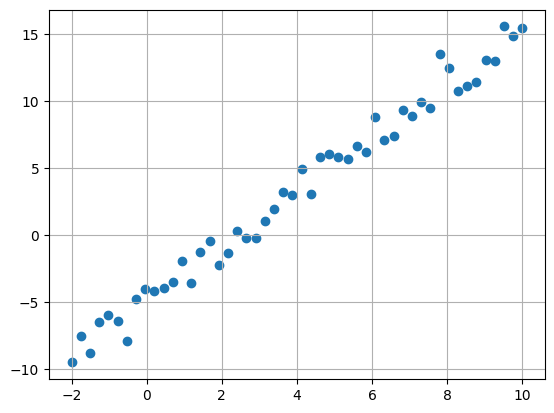

In [22]:
def f(x):
    y =2*x - 5
    noise = np.random.randn(*x.shape)
    return y + noise

x = np.linspace(-2, 10, 50)
y = f(x)

plt.scatter(x, y)
plt.grid()

In [ ]:
model = LinearRegression()
model.fit(x[:, None], y)
y_pred = model.predict(x[:, None])

In [ ]:
mse = mean_squared_error(y, y_pred)
print(np.sqrt(mse))

0.9417484056440233


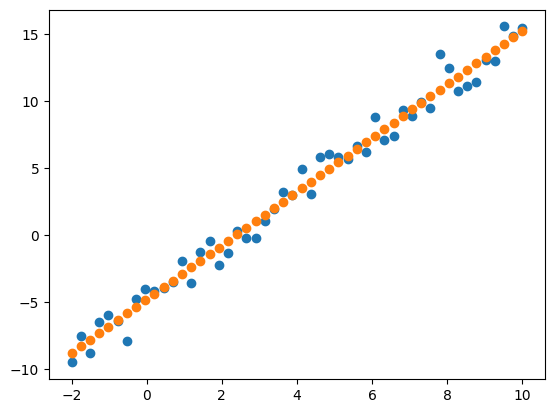

In [33]:
plt.scatter(x, y)
plt.scatter(x, y_pred)

In [34]:
model.coef_, model.intercept_

(array([2.00214555]), np.float64(-4.773451477819076))